In [73]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/niraliivaghani/flipkart-product-customer-reviews-dataset/Dataset-SA.csv


STEP 1
DATA LOADING

In [74]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import re
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')



import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
df = pd.read_csv('/kaggle/input/datasets/niraliivaghani/flipkart-product-customer-reviews-dataset/Dataset-SA.csv')


/kaggle/input/datasets/niraliivaghani/flipkart-product-customer-reviews-dataset/Dataset-SA.csv


STEP 2 & 3
DATA CLEANING AND PREPROCESSING

In [75]:
# Download necessary NLTK data
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# 1. Cleaning the Price and Text
def clean_data(df):
    # Remove currency symbol and commas from price
    if 'Product_price' in df.columns:
        df['Product_price'] = df['Product_price'].replace(r'[₹,]', '', regex=True).astype(float)
    
    # Fill missing reviews
    df['Summary'] = df['Summary'].fillna('no review')
    
    # Text preprocessing function
    def preprocess_text(text):
        text = text.lower()
        text = re.sub(r'[^a-z\s]', '', text) # Remove special characters/numbers
        words = text.split()
        words = [w for w in words if w not in stop_words] # Remove stopwords
        return " ".join(words)

    df['Clean_Summary'] = df['Summary'].apply(preprocess_text)
    return df

df = clean_data(df)

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


STEP 4

EDA (VISUALIZATION)

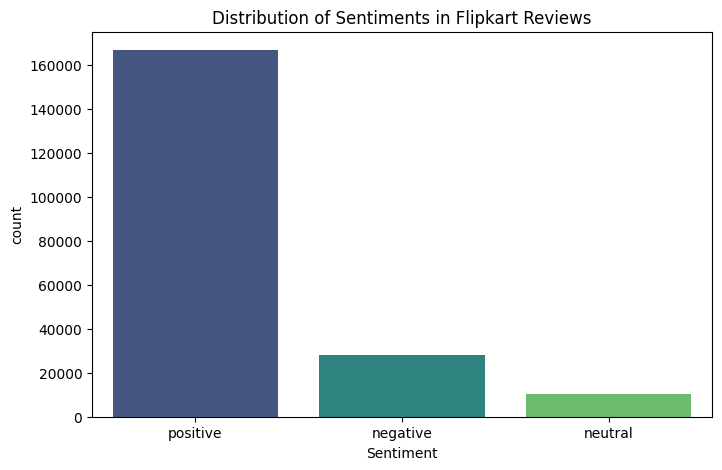

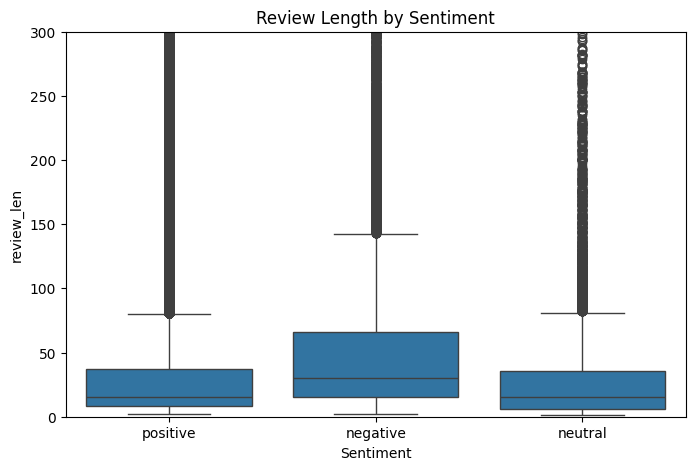

In [76]:
# Visualize the Class Imbalance
plt.figure(figsize=(8, 5))
sns.countplot(x='Sentiment', data=df, palette='viridis')
plt.title('Distribution of Sentiments in Flipkart Reviews')
plt.show()

# Quick look at Review Length vs Sentiment
df['review_len'] = df['Summary'].astype(str).apply(len)
plt.figure(figsize=(8, 5))
sns.boxplot(x='Sentiment', y='review_len', data=df)
plt.title('Review Length by Sentiment')
plt.ylim(0, 300) # Zoom in to see the bulk of reviews
plt.show()

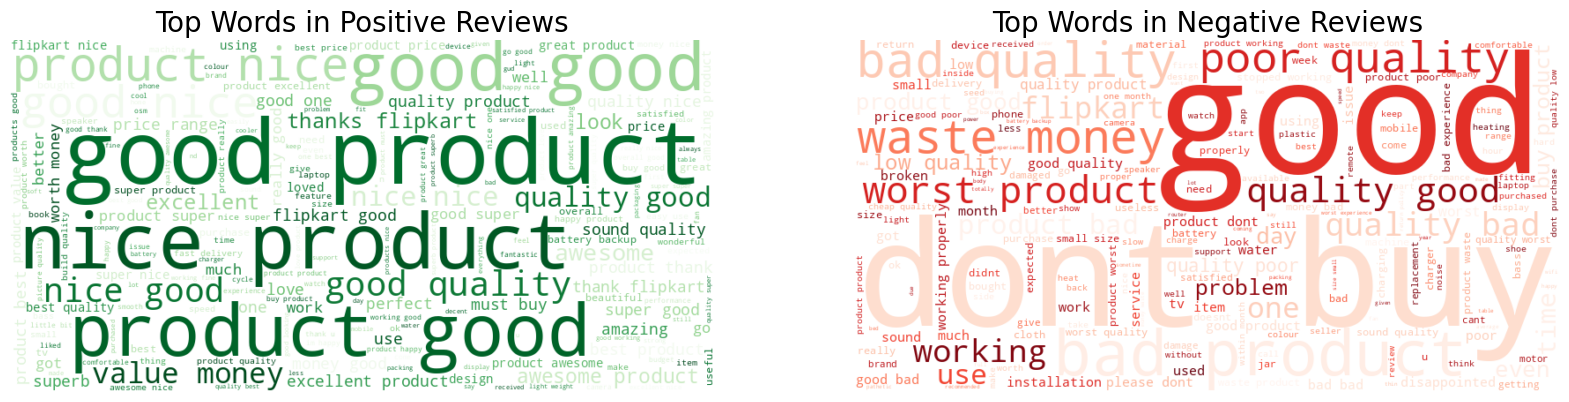

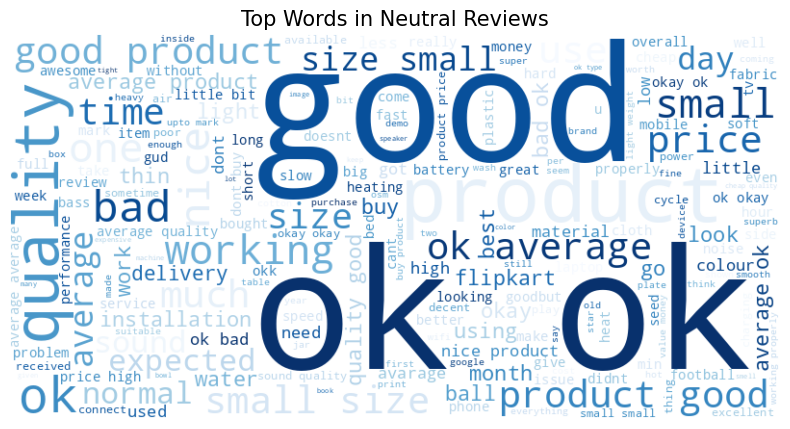

In [77]:
#WORDCLOUD
# 1. Separate the text by sentiment
positive_text = " ".join(df[df['Sentiment'] == 'positive']['Clean_Summary'])
negative_text = " ".join(df[df['Sentiment'] == 'negative']['Clean_Summary'])
neutral_text = " ".join(df[df['Sentiment'] == 'neutral']['Clean_Summary'])

# 2. Generate the WordClouds
wordcloud_pos = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(positive_text)
wordcloud_neg = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(negative_text)
wordcloud_neu = WordCloud(
    width=800, 
    height=400, 
    background_color='white', 
    colormap='Blues'
).generate(neutral_text)

# 3. Plotting
fig, ax = plt.subplots(1, 2, figsize=(20, 10))

ax[0].imshow(wordcloud_pos, interpolation='bilinear')
ax[0].set_title('Top Words in Positive Reviews', fontsize=20)
ax[0].axis('off')

ax[1].imshow(wordcloud_neg, interpolation='bilinear')
ax[1].set_title('Top Words in Negative Reviews', fontsize=20)
ax[1].axis('off')

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_neu, interpolation='bilinear')
plt.title('Top Words in Neutral Reviews', fontsize=15)
plt.axis('off')

plt.show()

STEP 5


FEATURE EXTRACTION (VECTORIZATION)

In [78]:
# Define features and target
X = df['Clean_Summary']
y = df['Sentiment']

# Split data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Vectorization
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

STEP 6
TRAINING AND EVALUATION

In [79]:
# Initialize and train the model
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

# Make predictions
y_pred = model.predict(X_test_tfidf)

# Results
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Confusion Matrix for visual check
conf_matrix = confusion_matrix(y_test, y_pred)
print("--- Confusion Matrix ---")
print(conf_matrix)

--- Classification Report ---
              precision    recall  f1-score   support

    negative       0.81      0.63      0.71      5557
     neutral       0.82      0.33      0.47      2033
    positive       0.91      0.98      0.95     33421

    accuracy                           0.90     41011
   macro avg       0.85      0.65      0.71     41011
weighted avg       0.89      0.90      0.89     41011

--- Confusion Matrix ---
[[ 3511    27  2019]
 [  253   679  1101]
 [  561   126 32734]]


ITERATION 1: BASELINE MODEL (NAIVE BAYES)

SUMMARY OF THE RESULT

Performance: Achieved a high overall accuracy of 90%.


The Problem: The model suffered from extreme Class Imbalance.


The Result: While it was excellent at identifying positive reviews, it was effectively blind to neutral ones, catching only 33% (Recall) of that category. This suggested the model was simply defaulting to the majority class rather than actually learning the nuances of the feedback.


ITERATION 2: HANDLING IMBALANCE (RANDOM FOREST WITH BALANCED WEIGHTS)

In [80]:
# 1. Vectorization
tfidf = TfidfVectorizer(max_features=2000, ngram_range=(1, 2))
X_tfidf = tfidf.fit_transform(df['Clean_Summary'])
y = df['Sentiment']

# 2. Split the data
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

# 3. Efficient Modeling with 'Balanced' Weights
# class_weight='balanced' handles the imbalance during training automatically
rf_model = RandomForestClassifier(
    n_estimators=100, 
    class_weight='balanced', 
    max_depth=20,     
    n_jobs=-1,        # Uses all your e
    random_state=42
)

rf_model.fit(X_train, y_train)

# 4. Evaluation
y_pred = rf_model.predict(X_test)
print("--- Balanced Model Results ---")
print(classification_report(y_test, y_pred))
print(conf_matrix)

--- Balanced Model Results ---
              precision    recall  f1-score   support

    negative       0.72      0.67      0.70      5557
     neutral       0.24      0.76      0.36      2033
    positive       0.97      0.85      0.91     33421

    accuracy                           0.82     41011
   macro avg       0.64      0.76      0.65     41011
weighted avg       0.90      0.82      0.85     41011

[[ 3511    27  2019]
 [  253   679  1101]
 [  561   126 32734]]


ITERATION 2: HANDLING IMBALANCE (RANDOM FOREST WITH BALANCED WEIGHTS)

SUMMARY OF RESULT

Sensitivity Focus (Random Forest with Balanced Weights)
Performance: Overall accuracy dropped to 82%, but the Macro Average Recall improved to 0.76.


The Shift: We introduced class_weight='balanced' to force the model to pay attention to minority classes.


The Result: The Neutral Recall jumped significantly from 0.33 to 0.76, meaning the model finally began identifying the majority of neutral reviews. However, the Precision for neutral was quite low (0.24), indicating the model was over-reporting neutral sentiments and creating noise.

ITERATION 3: OPTIMIZED LOGISTICS REGRESSION

In [81]:
# 1. Feature Extraction
# Use 3,000 features and Bigrams to capture "not happy" vs "happy"
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))
X_tfidf = tfidf.fit_transform(df['Clean_Summary'])
y = df['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

# 2. Model: Logistic Regression
model = LogisticRegression(
    class_weight='balanced', 
    max_iter=500,           
    solver='lbfgs',         
    multi_class='ovr' 
)

model.fit(X_train, y_train)

# 3.Evaluation
y_pred = model.predict(X_test)
print("--- Model Results ---")
print(classification_report(y_test, y_pred))
print(conf_matrix)

--- Model Results ---
              precision    recall  f1-score   support

    negative       0.69      0.79      0.74      5557
     neutral       0.33      0.69      0.45      2033
    positive       0.97      0.89      0.93     33421

    accuracy                           0.86     41011
   macro avg       0.67      0.79      0.70     41011
weighted avg       0.90      0.86      0.88     41011

[[ 3511    27  2019]
 [  253   679  1101]
 [  561   126 32734]]


ITERATION 3: OPTIMIZED LOGISTICS REGRESSION

SUMMARY OF RESULT

Performance: Reached a balanced accuracy of 86% with an improved Macro Avg F1-score of 0.70.
The Shift: We swapped to a linear model to sharpen the decision boundaries between categories and reduce the "noise" found in the previous iteration.
The Result: This iteration successfully sharpened the precision for neutral reviews to 0.33 while maintaining a solid 0.69 Recall. It represents the best balance as it remains sensitive enough to catch negative/neutral feedback without being as inaccurate as the second attempt.